In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler


In [2]:
# ==========================================
# 1. Configuration and Data Loading
# ==========================================

# Define dimensions
motor_dims = ['Foot', 'Hand', 'Head', 'Mouth', 'Torso']
sensory_dims = ['Auditory', 'Gustatory', 'Haptic', 'Interoceptive', 'Olfactory', 'Visual']
all_dims = motor_dims + sensory_dims


# Define models and their suffixes in Excel column names
models_info = {
    'Human': {'suffix': 'mean', 'sep': '.'},
    'Base':  {'suffix': 'base', 'sep': '_'},
    'En_FT': {'suffix': 'en_ft', 'sep': '_'},
    'Nl_FT': {'suffix': 'nl_ft', 'sep': '_'},
    'QA_FT': {'suffix': 'qa_ft', 'sep': '_'}
}

model_comparison_list = ['Base', 'En_FT', 'Nl_FT', 'QA_FT']

# Read data
file_path = "En_all_models_results.xlsx" 
print(f"Loading data from {file_path}...")
try:
    df = pd.read_excel(file_path)
    df.columns = df.columns.str.lower()
    print(f"Data loaded. Shape: {df.shape}")
except FileNotFoundError:
    print("Error: File not found. Please check the path.")

Loading data from En_all_models_results.xlsx...
Data loaded. Shape: (1572, 97)


In [3]:
# ==========================================
# 2. Helper Functions
# ==========================================

def get_feature_matrix(df, dims, model_key):
    """Extract feature matrix for a specific model and dimensions (N_words x N_dims)"""
    info = models_info[model_key]
    suffix = info['suffix']
    sep = info['sep']
    
    col_names = [f"{d.lower()}{sep}{suffix}" for d in dims]
    
    # Check if columns exist
    missing_cols = [c for c in col_names if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns for {model_key}: {missing_cols}")
        
    matrix = df[col_names].values
    # Normalize features (usually recommended before calculating distance)
    return StandardScaler().fit_transform(matrix)

def calculate_rdm(feature_matrix, metric='cosine'):
    """Calculate Representational Dissimilarity Matrix (RDM), return compressed upper triangular vector"""
    # pdist returns compressed distance matrix (only upper triangular part), which is what RSA needs
    return pdist(feature_matrix, metric=metric)

def bootstrap_test_difference(rds_human, rds_m1_cols, rds_m2_cols, n_boot=1000):
    """
    Bootstrap test for difference in correlation between two models and Human
    Note: For efficiency, we resample 'word samples' here, not the large RDM vectors directly
    """
    n_samples = rds_m1_cols.shape[0] # Number of words
    
    diffs = []
    boot_r1s = []
    boot_r2s = []
    
    # Original correlation
    rdm_human = pdist(rds_human, 'cosine')
    
    # Handle possible nans in original data (caused by 0 vectors)
    rdm_human = np.nan_to_num(rdm_human, nan=2.0)
    
    # Helper calculation function
    def safe_spearman(h, m):
        if np.std(m) == 0: return 0.0
        r = spearmanr(h, m).correlation
        return 0.0 if np.isnan(r) else r

    r1 = safe_spearman(rdm_human, np.nan_to_num(pdist(rds_m1_cols, 'cosine'), nan=2.0))
    r2 = safe_spearman(rdm_human, np.nan_to_num(pdist(rds_m2_cols, 'cosine'), nan=2.0))
    actual_diff = r1 - r2
    
    print(f"  > Bootstrapping (n={n_boot})...")
    
    for _ in range(n_boot):
        # Resample indices
        indices = np.random.choice(n_samples, n_samples, replace=True)
        
        # Build new temporary feature matrix based on resampled words
        boot_human = rds_human[indices]
        boot_m1 = rds_m1_cols[indices]
        boot_m2 = rds_m2_cols[indices]
        
        # Calculate RDM and handle Nan
        d_human = np.nan_to_num(pdist(boot_human, 'cosine'), nan=2.0)
        d_m1 = np.nan_to_num(pdist(boot_m1, 'cosine'), nan=2.0)
        d_m2 = np.nan_to_num(pdist(boot_m2, 'cosine'), nan=2.0)
        
        # Calculate correlation
        corr1 = safe_spearman(d_human, d_m1)
        corr2 = safe_spearman(d_human, d_m2)
        
        diffs.append(corr1 - corr2)
        boot_r1s.append(corr1) # [Record]
        boot_r2s.append(corr2) # [Record]
        
    diffs = np.array(diffs)
    # Calculate P-value (two-tailed)
    p_value = np.mean(np.abs(diffs - np.mean(diffs)) >= np.abs(actual_diff)) # This is an approximation
  
    # Check if 0 is in the 95% confidence interval
    ci_lower = np.percentile(diffs, 2.5)
    ci_upper = np.percentile(diffs, 97.5)
    
    sig = False
    if ci_lower > 0 or ci_upper < 0:
        sig = True

    return actual_diff, p_value, sig, (ci_lower, ci_upper), boot_r1s, boot_r2s

In [ ]:
# ==========================================
# 3. Main Analysis Loop (Full Data Recording Version)
# ==========================================

# Prepare containers
all_rsa_scores_data = []      # Store RSA correlation coefficients
all_rdm_storage = {}          # Store raw RDM vectors (for heatmaps)
all_bootstrap_details = []    # Store distribution data for 200 bootstrap iterations
all_stats_summary = []        # Store statistical significance summary


# For English dataset:
analysis_configs = {'Motor': motor_dims, 'Sensory': sensory_dims, 'All': all_dims}


for analysis_type, dims in analysis_configs.items():
    if df.empty: break
    print(f"\n{'='*20}\nRunning RSA for: {analysis_type}\n{'='*20}")
    
    # --- 1. Data Preparation ---
    all_rdm_storage[analysis_type] = {} # Initialize RDM storage for this type
    
    needed_cols = []
    # Concatenate column names
    human_suffix = models_info['Human']['suffix']
    human_sep = models_info['Human']['sep']
    needed_cols.extend([f"{d.lower()}{human_sep}{human_suffix}" for d in dims])
    
    for m in model_comparison_list:
        info = models_info[m]
        needed_cols.extend([f"{d.lower()}{info['sep']}{info['suffix']}" for d in dims])
        
    df_clean = df[needed_cols].dropna()
    print(f"  > Valid words (no NaNs): {len(df_clean)}")
    
    # --- 2. Calculate Human RDM ---
    matrix_human = get_feature_matrix(df_clean, dims, 'Human')
    rdm_human_vec = calculate_rdm(matrix_human, metric='cosine')
    rdm_human_vec = np.nan_to_num(rdm_human_vec, nan=2.0)
    
    # Store Human RDM (vector form)
    all_rdm_storage[analysis_type]['Human'] = rdm_human_vec

    feature_matrices = {} # Temporarily store for Bootstrap
    
    # --- 3. Calculate Model RSA ---
    for model_name in model_comparison_list:
        mat = get_feature_matrix(df_clean, dims, model_name)
        feature_matrices[model_name] = mat
        
        # RDM
        rdm_vec = calculate_rdm(mat, metric='cosine')
        rdm_vec = np.nan_to_num(rdm_vec, nan=2.0)
        all_rdm_storage[analysis_type][model_name] = rdm_vec # Store
        
        # Correlation
        rho, p = spearmanr(rdm_human_vec, rdm_vec)
        if np.isnan(rho): rho = 0.0
        
        print(f"Model: {model_name:<10} | rho: {rho:.4f}")
        
        all_rsa_scores_data.append({
            'Analysis_Type': analysis_type,
            'Model': model_name,
            'Spearman_Rho': rho,
            'P_Value': p
        })

    # --- 4. Statistical Test (Bootstrap) & Distribution Recording ---
    print(f"\n--- Bootstrap Test (200 iter) ---")
    n_boot_iter = 200
    
    # Define model pairs to compare
    comparisons = [('Nl_FT', 'Base'), ('En_FT', 'Base'), ('En_FT', 'Nl_FT'), ('QA_FT', 'Nl_FT'), ('QA_FT', 'Base'), ('En_FT', 'QA_FT')]
    
    
    for m1, m2 in comparisons:
        # Call function (ensure it returns 6 values: diff, p, sig, ci, boot_r1s, boot_r2s)
        diff, p, is_sig, ci, boot_r1s, boot_r2s = bootstrap_test_difference(
            matrix_human, 
            feature_matrices[m1], 
            feature_matrices[m2], 
            n_boot=n_boot_iter
        )
        
        sig_str = "*" if is_sig else "ns"
        print(f"{m1} vs {m2:<10} | Diff: {diff:.4f} | {sig_str}")
        
        # Record summary
        all_stats_summary.append({
            'Analysis_Type': analysis_type,
            'Comparison': f"{m1} vs {m2}",
            'Diff': diff,
            'P_Value': p,
            'CI_Lower': ci[0],
            'CI_Upper': ci[1],
            'Significant': sig_str
        })
        
        # Record detailed distribution (Core step)
        boot_diffs = [a - b for a, b in zip(boot_r1s, boot_r2s)]
        all_bootstrap_details.append({
            'Analysis_Type': analysis_type,
            'Comparison': f"{m1} vs {m2}",
            'Boot_RSA_M1': boot_r1s,  # List [0.4, 0.42, ...]
            'Boot_RSA_M2': boot_r2s,  # List [0.35, 0.36, ...]
            'Boot_Diffs': boot_diffs, # Store list
            'CI_Lower': ci[0],
            'CI_Upper': ci[1]
        })

# Convert to DataFrame for plotting
df_rsa_scores = pd.DataFrame(all_rsa_scores_data)
df_bootstrap = pd.DataFrame(all_bootstrap_details)

print("\nAnalysis complete, data stored.")

In [ ]:
# ==========================================
# 4. Visualization (Three Types of Plots)
# ==========================================

import seaborn as sns
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list

# Set plot style
sns.set_theme(style="whitegrid")

# --- Plot 1: RSA Results Bar Chart ---
def plot_rsa_bars(df_scores):
    g = sns.catplot(
        data=df_scores, 
        kind="bar",
        x="Analysis_Type", 
        y="Spearman_Rho", 
        hue="Model",
        palette="viridis",
        alpha=0.9,
        height=5, 
        aspect=1.5
    )
    g.despine(left=True)
    g.set_axis_labels("Analysis Dimension", "RSA Score (Spearman rho)")
    g.legend.set_title("Model")
    plt.title("RSA Model Performance Comparison", pad=20)
    plt.ylim(0, df_scores['Spearman_Rho'].max() * 1.2)
    
    # Add value labels
    ax = g.facet_axis(0, 0)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f', padding=3)
    plt.show()


# --- Improved Plot 2: Structured RDM Heatmap (Sorted by Human Clustering) ---
def plot_structured_rdm_heatmap(rdm_storage, analysis_type, model_list, subset_n=50):
    """
    Plot sorted RDM heatmap.
    Principle: Perform hierarchical clustering on the top subset_n words of Human RDM to get sort indices that group similar words.
    Then use these indices to reorder RDMs of all models.
    This way, if a model is similar to human, it will show clear block structures; if messy, structure mismatch.
    """
    if analysis_type not in rdm_storage: return
    
    # 1. Prepare Human RDM subset for calculating sort order
    human_rdm_vec = rdm_storage[analysis_type]['Human']
    human_rdm_sq = squareform(human_rdm_vec)
    
    # Subset
    subset_human_sq = human_rdm_sq[:subset_n, :subset_n]
    
    # === Key Step: Calculate Clustering Sort Order ===
    # Convert square matrix back to compressed vector for linkage
    subset_human_vec = squareform(subset_human_sq, checks=False) 
    # Use Ward method for clustering
    Z = linkage(subset_human_vec, method='ward')
    # Get sorted index list
    sort_idx = leaves_list(Z)
    
    # --- Start Plotting ---
    plot_models = ['Human'] + model_list
    n_models = len(plot_models)
    
    fig, axes = plt.subplots(1, n_models, figsize=(3.5 * n_models, 3.5))
    if n_models == 1: axes = [axes]
    
    for ax, model in zip(axes, plot_models):
        if model not in rdm_storage[analysis_type]: continue
        
        # Get raw matrix & subset
        rdm_vec = rdm_storage[analysis_type][model]
        rdm_sq = squareform(rdm_vec)
        subset_sq = rdm_sq[:subset_n, :subset_n]
        
        # === Apply Sorting ===
        # Rows and columns must be rearranged according to Human clustering order
        sorted_sq = subset_sq[sort_idx, :][:, sort_idx]
        
        # Plot
        # vmin/vmax fixed range ensures comparable color intensity across models
        # viridis_r: Yellow=Close(Similar), Dark Purple=Far(Dissimilar) -> Visually like "Spotlight" effect
        sns.heatmap(sorted_sq, ax=ax, cmap="viridis_r", square=True, 
                    cbar=True, vmin=0.0, vmax=1.2,
                    xticklabels=False, yticklabels=False)
        
        ax.set_title(f"{model}\n(Sorted by Human)", fontsize=11)
        ax.set_xlabel(f"Top {subset_n} Words (Clustered)")
    
    plt.suptitle(f"Structural Alignment Check ({analysis_type})", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()


# --- Plot 3: Bootstrap RSA Density Curve (Replacing original Difference Curve) ---
def plot_bootstrap_rsa_density(df_details, analysis_type):
    """
    Plot RSA Score Distribution Density for 200 iterations
    Show correlation distribution of each model during Bootstrap resampling
    """
    # Filter data for current analysis type
    subset = df_details[df_details['Analysis_Type'] == analysis_type]
    
    if subset.empty: 
        print(f"No bootstrap details found for {analysis_type}")
        return

    plt.figure(figsize=(10, 6))
    
    # Extract unique model distribution data
    # Note: A model may appear in multiple Comparisons (e.g. En_FT vs Base, QA_FT vs Base)
    # Although each Comparison is an independent Bootstrap resampling, the distribution is theoretically consistent
    # We take the distribution data from the first appearance of the model as representative
    
    model_distributions = {}
    
    for _, row in subset.iterrows():
        comp_str = row['Comparison']
        # Parse Comparison string, e.g., "En_FT vs Base"
        if " vs " in comp_str:
            parts = comp_str.split(" vs ")
            if len(parts) == 2:
                m1, m2 = parts
                
                # If model hasn't been recorded, record it
                if m1 not in model_distributions:
                    model_distributions[m1] = row['Boot_RSA_M1']
                if m2 not in model_distributions:
                    model_distributions[m2] = row['Boot_RSA_M2']

    # Plot KDE Density
    if not model_distributions:
        print("Could not parse models from Comparison column (expected format 'Model1 vs Model2').")
        return
        
    # Define colors (use Seaborn palette)
    palette = sns.color_palette("bright", len(model_distributions))
    
    for i, (model_name, scores) in enumerate(model_distributions.items()):
        sns.kdeplot(
            scores, 
            fill=True, 
            label=model_name, 
            alpha=0.3, 
            color=palette[i],
            linewidth=2
        )

    plt.title(f"Bootstrap RSA Score Distribution ({analysis_type}) - 200 Iterations", fontsize=14)
    plt.xlabel("RSA Score (Spearman Correlation)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.legend(title="Model", title_fontsize='11', fontsize='10')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()


=== Visualization 1: RSA Scores ===


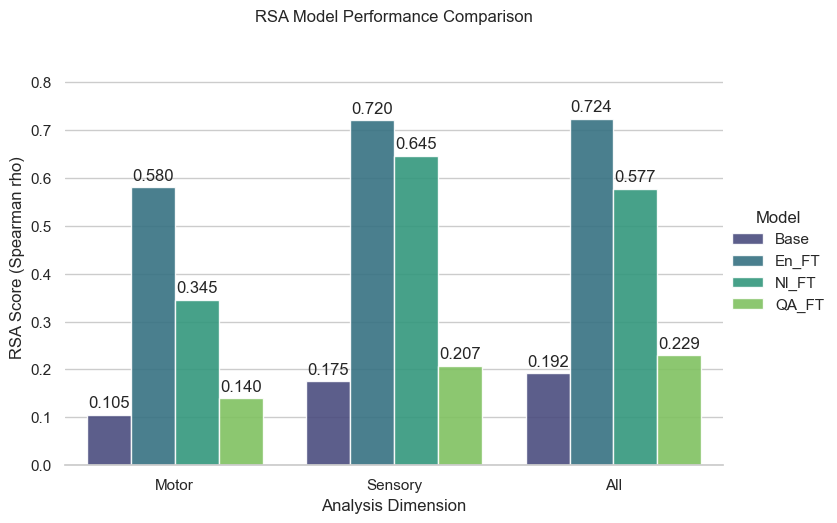


=== Visualization 2: RDM Heatmaps (Sensory Example) ===


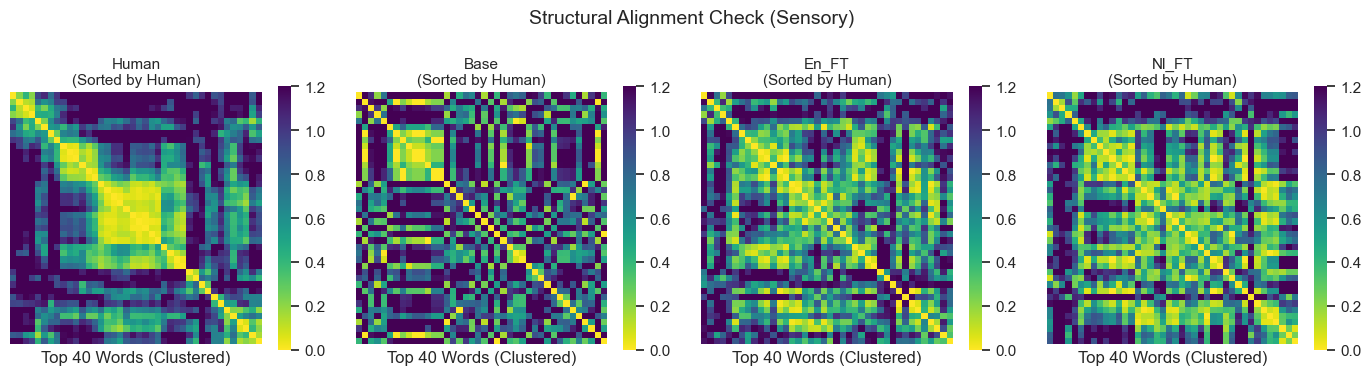


=== Visualization 3: Bootstrap RSA Densities ===


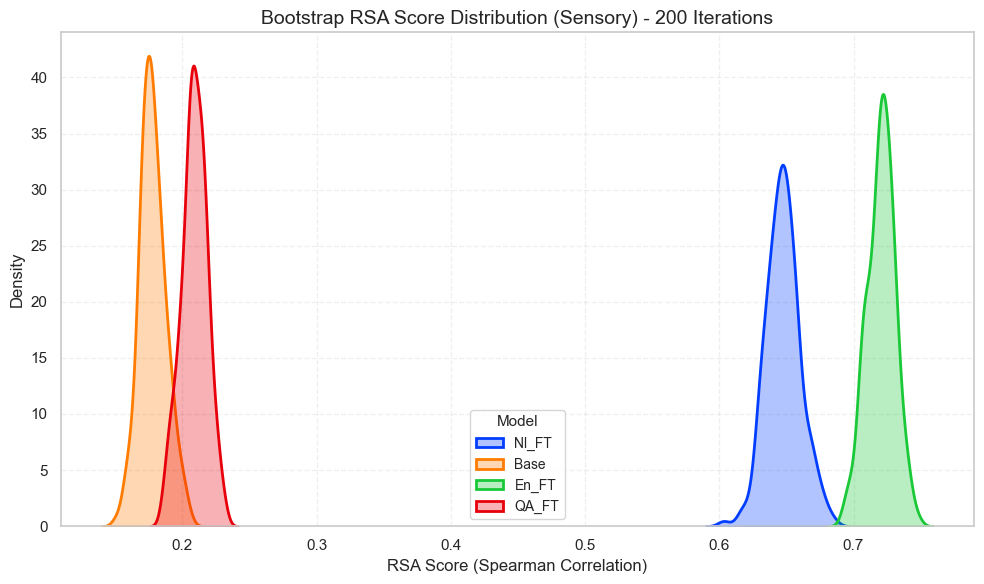

In [ ]:
# --- Execute Plotting ---
print("\n=== Visualization 1: RSA Scores ===")
plot_rsa_bars(df_rsa_scores)

print("\n=== Visualization 2: RDM Heatmaps (Sensory Example) ===")
# Assume we only plot Sensory heatmaps
plot_structured_rdm_heatmap(all_rdm_storage, 'Sensory', model_comparison_list, subset_n=40)

print("\n=== Visualization 3: Bootstrap RSA Densities ===")
# Iterate through each analysis type in config to plot
for a_type in analysis_configs.keys():
    plot_bootstrap_rsa_density(df_bootstrap, a_type)

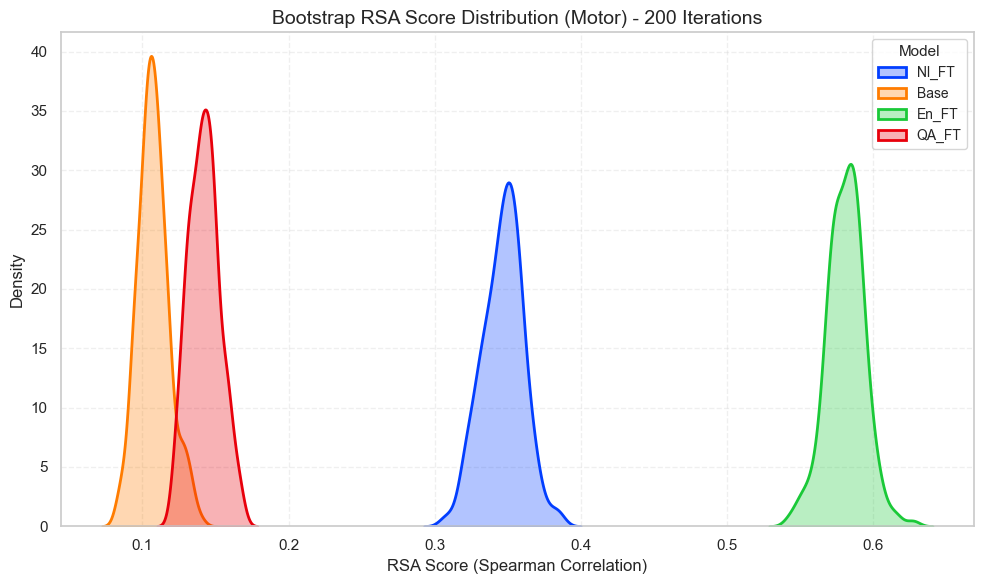

In [29]:
plot_bootstrap_rsa_density(df_bootstrap, 'Motor')

In [ ]:
model_comparison_list = ['Base', 'En_FT', 'Nl_FT', 'QA_FT']
plot_structured_rdm_heatmap(all_rdm_storage, 'All', model_comparison_list, subset_n=40)

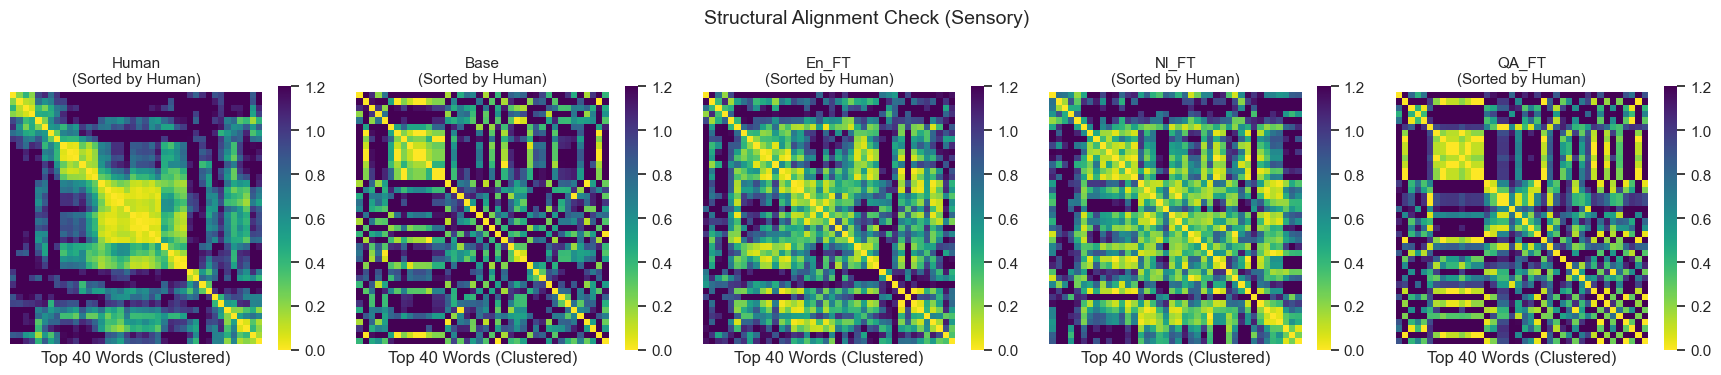

In [28]:
plot_structured_rdm_heatmap(all_rdm_storage, 'Sensory', model_comparison_list, subset_n=40)


## Dutch

In [6]:
# ==========================================
# 1. Configuration and Data Loading
# ==========================================

# Define dimensions
nl_dims = ["Horen", "Proeven", "Voelen", "Sensaties", "Ruiken", "Zien"]


# Define models and their suffixes in Excel column names
# Note: Based on previous notebooks, Human uses dot separator (.mean), models use underscore (_base)
models_info = {
    'Human': {'suffix': '', 'sep': ''},
    'Base':  {'suffix': 'base', 'sep': '_'},
    'En_FT': {'suffix': 'en_ft', 'sep': '_'},
    'Nl_FT': {'suffix': 'nl_ft', 'sep': '_'}
}

model_comparison_list = ['Base', 'En_FT', 'Nl_FT']

# Read data
file_path = "Nl_all_models_results.xlsx" 
print(f"Loading data from {file_path}...")
try:
    df_nl = pd.read_excel(file_path)
    df_nl.columns = df_nl.columns.str.lower()
    print(f"Data loaded. Shape: {df_nl.shape}")
except FileNotFoundError:
    print("Error: File not found. Please check the path.")

Loading data from Nl_all_models_results.xlsx...
Data loaded. Shape: (1572, 71)


In [ ]:
# ==========================================
# 3. Main Analysis Loop (Full Data Recording Version)
# ==========================================

# Prepare containers
nl_rsa_scores_data = []      # Store RSA correlation coefficients
nl_rdm_storage = {}          # Store raw RDM vectors (for heatmaps)
nl_bootstrap_details = []    # Store distribution data for 200 bootstrap iterations
nl_stats_summary = []        # Store statistical significance summary

# Ensure analysis_configs is defined (Motor/Sensory or Nl_dims based on context)
analysis_configs = {'Sensory': nl_dims}


for analysis_type, dims in analysis_configs.items():
    if df.empty: break
    print(f"\n{'='*20}\nRunning RSA for: {analysis_type}\n{'='*20}")
    
    # --- 1. Data Preparation ---
    nl_rdm_storage[analysis_type] = {} # Initialize RDM storage for this type
    
    needed_cols = []
    # Concatenate column names
    human_suffix = models_info['Human']['suffix']
    human_sep = models_info['Human']['sep']
    needed_cols.extend([f"{d.lower()}{human_sep}{human_suffix}" for d in dims])
    
    for m in model_comparison_list:
        info = models_info[m]
        needed_cols.extend([f"{d.lower()}{info['sep']}{info['suffix']}" for d in dims])
        
    df_clean = df_nl[needed_cols].dropna()
    print(f"  > Valid words (no NaNs): {len(df_clean)}")
    
    # --- 2. Calculate Human RDM ---
    matrix_human = get_feature_matrix(df_clean, dims, 'Human')
    rdm_human_vec = calculate_rdm(matrix_human, metric='cosine')
    rdm_human_vec = np.nan_to_num(rdm_human_vec, nan=2.0)
    
    # Store Human RDM (vector form)
    nl_rdm_storage[analysis_type]['Human'] = rdm_human_vec

    feature_matrices = {} # Temporarily store for Bootstrap
    
    # --- 3. Calculate Model RSA ---
    for model_name in model_comparison_list:
        mat = get_feature_matrix(df_clean, dims, model_name)
        feature_matrices[model_name] = mat
        
        # RDM
        rdm_vec = calculate_rdm(mat, metric='cosine')
        rdm_vec = np.nan_to_num(rdm_vec, nan=2.0)
        nl_rdm_storage[analysis_type][model_name] = rdm_vec # Store
        
        # Correlation
        rho, p = spearmanr(rdm_human_vec, rdm_vec)
        if np.isnan(rho): rho = 0.0
        
        print(f"Model: {model_name:<10} | rho: {rho:.4f}")

        nl_rsa_scores_data.append({
            'Analysis_Type': analysis_type,
            'Model': model_name,
            'Spearman_Rho': rho,
            'P_Value': p
        })

    # --- 4. Statistical Test (Bootstrap) & Distribution Recording ---
    print(f"\n--- Bootstrap Test (200 iter) ---")
    n_boot_iter = 200
    
    # Define model pairs to compare
    # Adjust dynamically based on your model list, or hardcode
    comparisons = [('Nl_FT', 'Base'), ('En_FT', 'Base'), ('En_FT', 'Nl_FT')]
    
    
    for m1, m2 in comparisons:
        # Call function (ensure it returns 6 values: diff, p, sig, ci, boot_r1s, boot_r2s)
        diff, p, is_sig, ci, boot_r1s, boot_r2s = bootstrap_test_difference(
            matrix_human, 
            feature_matrices[m1], 
            feature_matrices[m2], 
            n_boot=n_boot_iter
        )
        
        sig_str = "*" if is_sig else "ns"
        print(f"{m1} vs {m2:<10} | Diff: {diff:.4f} | {sig_str}")
        
        # Record summary
        nl_stats_summary.append({
            'Analysis_Type': analysis_type,
            'Comparison': f"{m1} vs {m2}",
            'Diff': diff,
            'P_Value': p,
            'CI_Lower': ci[0],
            'CI_Upper': ci[1],
            'Significant': sig_str
        })
        
        # Record detailed distribution (Core step)
        boot_diffs = [a - b for a, b in zip(boot_r1s, boot_r2s)]
        nl_bootstrap_details.append({
            'Analysis_Type': analysis_type,
            'Comparison': f"{m1} vs {m2}",
            'Boot_RSA_M1': boot_r1s,  # List [0.4, 0.42, ...]
            'Boot_RSA_M2': boot_r2s,  # List [0.35, 0.36, ...]
            'Boot_Diffs': boot_diffs, # Store list
            'CI_Lower': ci[0],
            'CI_Upper': ci[1]
        })

# Convert to DataFrame for plotting
df_nl_rsa_scores = pd.DataFrame(nl_rsa_scores_data)
df_nl_bootstrap = pd.DataFrame(nl_bootstrap_details)

print("\nAnalysis complete, data stored.")


Running RSA for: Sensory
  > Valid words (no NaNs): 1572
Model: Base       | rho: 0.1247
Model: En_FT      | rho: 0.6413
Model: Nl_FT      | rho: 0.7209

--- Bootstrap Test (200 iter) ---
  > Bootstrapping (n=200)...
Nl_FT vs Base       | Diff: 0.5962 | *
  > Bootstrapping (n=200)...
En_FT vs Base       | Diff: 0.5166 | *
  > Bootstrapping (n=200)...
En_FT vs Nl_FT      | Diff: -0.0796 | *

分析完成，数据已存储。



=== Visualization 1: RSA Scores ===


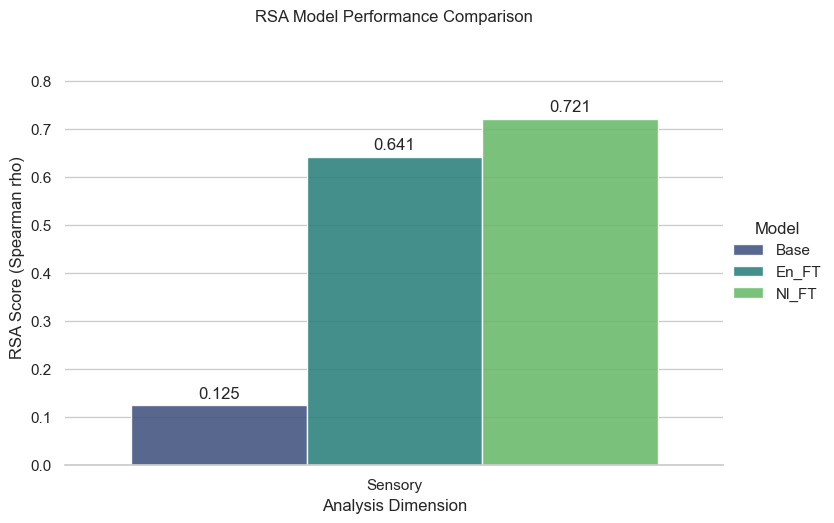


=== Visualization 2: RDM Heatmaps (Sensory Example) ===


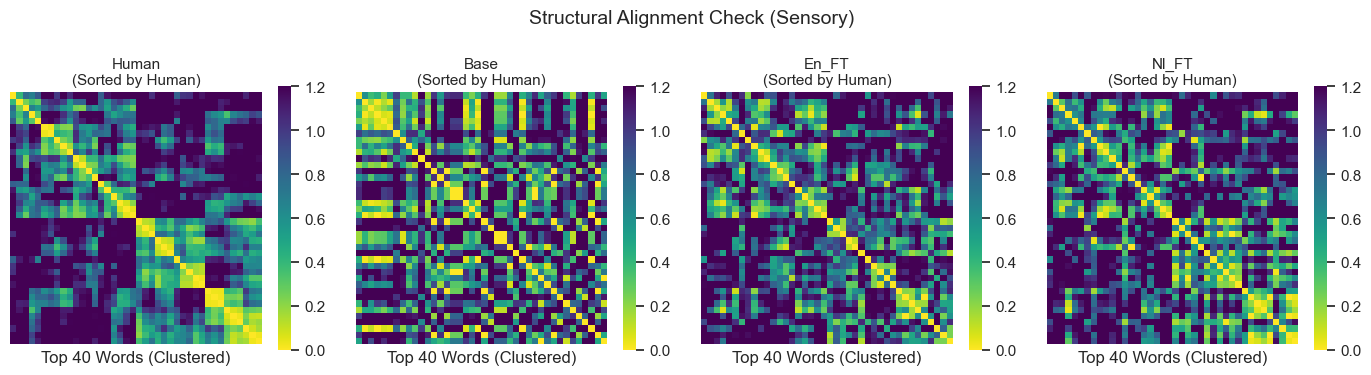


=== Visualization 3: Bootstrap RSA Densities ===


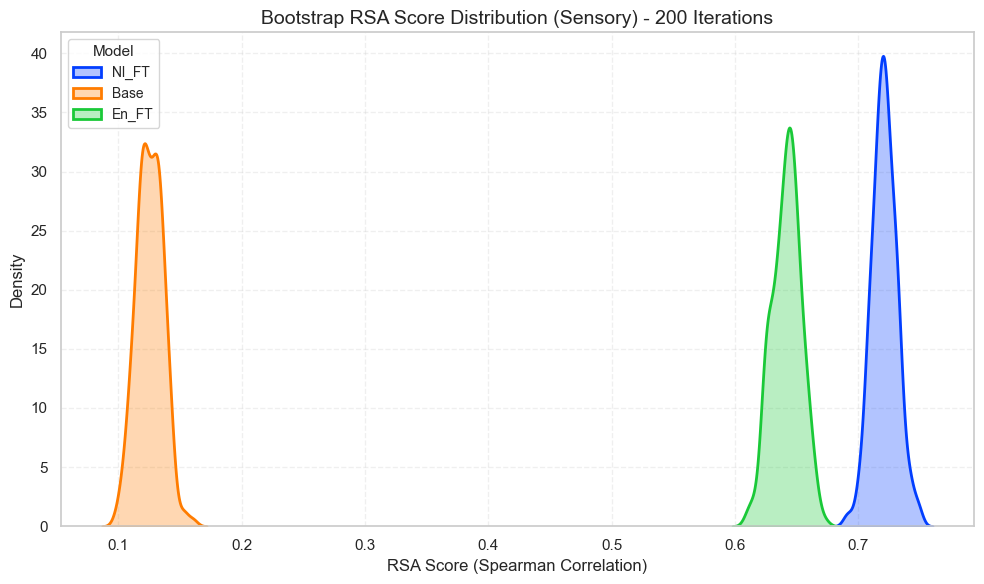

In [ ]:
# --- Execute Plotting ---
print("\n=== Visualization 1: RSA Scores ===")
plot_rsa_bars(df_nl_rsa_scores)

print("\n=== Visualization 2: RDM Heatmaps (Sensory Example) ===")
# Assume we only plot Sensory heatmaps
plot_structured_rdm_heatmap(nl_rdm_storage, 'Sensory', model_comparison_list, subset_n=40)

print("\n=== Visualization 3: Bootstrap RSA Densities ===")
# Iterate through each analysis type in config to plot
for a_type in analysis_configs.keys():
    plot_bootstrap_rsa_density(df_nl_bootstrap, a_type)